In [7]:
!pip install yfinance

236.58s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg

In [3]:


# choisir une entreprise
ticker = "AAPL"

# télécharger les données
df = yf.download(ticker, start="2018-01-01")

# garder uniquement le prix de clôture
close = df["Close"]

# afficher les premières lignes
print(close)

[*********************100%***********************]  1 of 1 completed

Ticker            AAPL
Date                  
2018-01-02   40.304180
2018-01-03   40.297157
2018-01-04   40.484344
2018-01-05   40.945259
2018-01-08   40.793190
...                ...
2026-03-03  263.750000
2026-03-04  262.519989
2026-03-05  260.290009
2026-03-06  257.459991
2026-03-09  259.880005

[2056 rows x 1 columns]


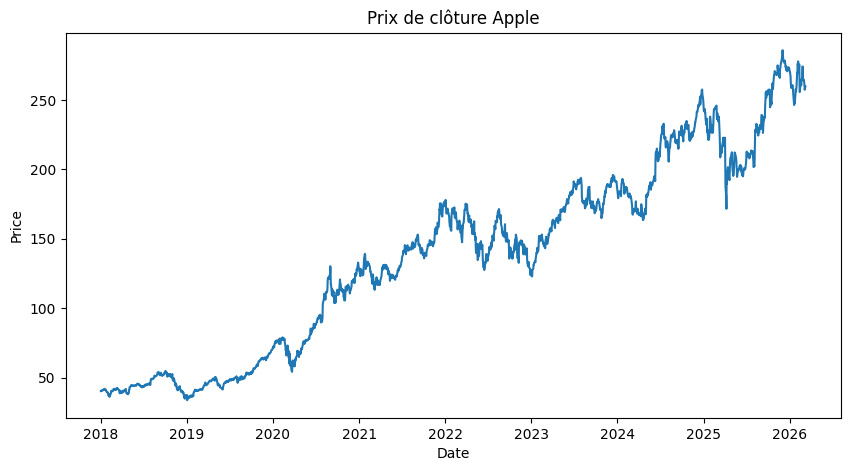

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(close)
plt.title("Prix de clôture Apple")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:


result = adfuller(close.dropna())

print("ADF statistic:", result[0])
print("p-value:", result[1])

#On ne rejette pas H0
#La série des prix de l’action est non stationnaire.

ADF statistic: -0.5660982195294223
p-value: 0.8784599249784406


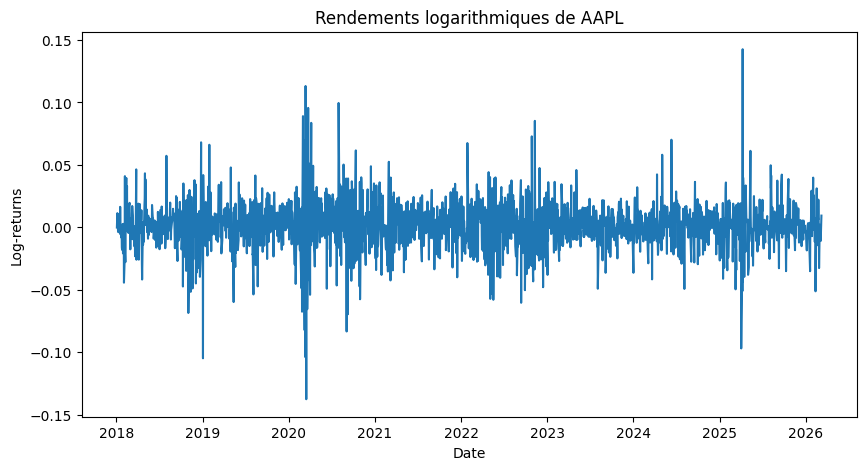


=== Test ADF sur les rendements ===
ADF statistic : -14.938378891825685
p-value : 1.3339665376702088e-27

=== Résultats du modèle AR(5) ===
                            AutoReg Model Results                             
Dep. Variable:                   AAPL   No. Observations:                 2055
Model:                     AutoReg(5)   Log Likelihood                5185.888
Method:               Conditional MLE   S.D. of innovations              0.019
Date:                Tue, 10 Mar 2026   AIC                         -10357.775
Time:                        11:17:21   BIC                         -10318.396
Sample:                             5   HQIC                        -10343.334
                                 2055                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.000      2.275      0.023       0.000   

/opt/python/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:

# 5. Calcul des rendements logarithmiques
returns = np.log(close / close.shift(1)).dropna()

# 6. Tracer les rendements
plt.figure(figsize=(10,5))
plt.plot(returns)
plt.title(f"Rendements logarithmiques de {ticker}")
plt.xlabel("Date")
plt.ylabel("Log-returns")
plt.show()

# 7. Test ADF sur les rendements
adf_returns = adfuller(returns)
print("\n=== Test ADF sur les rendements ===")
print("ADF statistic :", adf_returns[0])
print("p-value :", adf_returns[1])


model = AutoReg(returns, lags=5)
results = model.fit()

print("\n=== Résultats du modèle AR(5) ===")
print(results.summary())